# Heart Disease Prediction - Modelling
### Objective:
- Train and evaluate multiple machine learning models to predict heart disease.
- Perform hyperparameter tuning to optimize model performance.
- Compare model performance using statistical tests to determine if differences are significant.
### Models to Train:
1. Logistic Regression (Baseline)
2. Logistic Regression with Feature Engineering
3. XGBoost Classifier
4. Random Forest Classifier

## 1. Imports and setup

In [65]:
# Standard Data Science Libraries
import numpy as np
import pandas as pd

# Utilities Libraries
from pathlib import Path
from itertools import combinations
import yaml
import os
import joblib

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Statistics Libraries
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# Sklearn
from sklearn.model_selection import (
   StratifiedKFold, cross_val_score, RandomizedSearchCV, train_test_split
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_recall_curve

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Experiment tracking
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.tracking import MlflowClient

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [66]:
# Artifact directories

def resolve_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'artifacts').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

PROJECT_ROOT = resolve_project_root(Path.cwd())
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
PLOTS_DIR = ARTIFACTS_DIR / 'plots'
MODELS_DIR = ARTIFACTS_DIR / 'models'

for directory in (PLOTS_DIR, MODELS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

In [67]:
# Auto-save each displayed matplotlib figure (idempotent wrapper)
# Auto-save each displayed matplotlib figure
PLOT_PREFIX = '02_modelling'
_plot_counter = 0

def show_and_save(*args, **kwargs):
    global _plot_counter
    fig = plt.gcf()
    if fig.get_axes():
        _plot_counter += 1
        plot_path = PLOTS_DIR / f"{PLOT_PREFIX}_plot_{_plot_counter:02d}.png"
        fig.savefig(plot_path, dpi=300, bbox_inches='tight')
        display(fig)
        plt.close(fig)

plt.show = show_and_save
models_to_save = {}
print(f"Plots will be saved to: {PLOTS_DIR}")
print(f"Models will be saved to: {MODELS_DIR}")

Plots will be saved to: c:\Users\biell\Documents\projects\potfolio\Predicting-Heart-Disease\artifacts\plots
Models will be saved to: c:\Users\biell\Documents\projects\potfolio\Predicting-Heart-Disease\artifacts\models


In [68]:
# Ensure reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Loading and preparing the data

In [69]:
# Load the data
heart_data = pd.read_csv("./data/heart_disease_cleaned.csv")
heart_data.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,male,4,152,239,False,0,158,yes,3.6,2,2,7,Presence
1,1,52,male,1,125,325,False,2,171,no,0.0,1,0,3,Absence
2,2,56,female,2,160,188,False,2,151,no,0.0,1,0,3,Absence
3,3,44,female,3,134,229,False,2,150,no,1.0,2,0,3,Absence
4,4,58,male,4,140,234,False,2,125,yes,3.8,2,3,3,Presence


In [70]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  object 
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  bool   
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  object 
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [71]:
# Transform categorical variables
categorical_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
                    'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']

for col in categorical_cols:
    heart_data[col] = heart_data[col].astype('category')

categorical_features = categorical_cols[:-1]
numerical_features = [col for col in heart_data.columns if col not in categorical_cols and col != 'id']

In [72]:
# Split the data into features and target
X = heart_data.drop(['id', 'Heart Disease'], axis=1)
y = (heart_data['Heart Disease'] == "Presence").astype(int)
print(f"Shape of X: {X.shape}")
print(f"y value counts:\n{y.value_counts()}")

Shape of X: (630000, 13)
y value counts:
Heart Disease
0    347546
1    282454
Name: count, dtype: int64


In [73]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

## 3. Baseline model and evaluation

In [74]:
# Define a logistic regression pipeline and evaluate it using cross-validation
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(baseline_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Baseline Logistic Regression AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Baseline Logistic Regression AUC-ROC: 0.9527 ± 0.0008


## 4. Basic feature engineering

In [75]:
# Create a new feature: Age group
def age_group(age):
    if age < 40:
        return 'Under 40'
    elif 40 <= age < 50:
        return '40-49'
    elif 50 <= age < 60:
        return '50-59'
    else:
        return '60 and above'

In [76]:
# Create a new feature: High cholesterol indicator
def high_cholesterol(cholesterol):
    return int(cholesterol > 240)

In [77]:
# Create a new feature: Age Cholesterol interaction
def age_cholesterol_interaction(age, cholesterol):
    return age * cholesterol

In [78]:
# Create a new feature: Blood Pressure Category
def bp_category(bp):
    if bp < 120:
        return 'Normal'
    elif 120 <= bp < 130:
        return 'Elevated'
    elif 130 <= bp < 140:
        return 'Hypertension Stage 1'
    else:
        return 'Hypertension Stage 2'

In [79]:
# Function to create all new features
def create_features(df):
    df['Age Group'] = df['Age'].apply(age_group)
    df['High Cholesterol'] = df['Cholesterol'].apply(high_cholesterol)
    df['Age_Cholesterol'] = df.apply(lambda row: age_cholesterol_interaction(row['Age'], row['Cholesterol']), axis=1)
    df['BP Category'] = df['BP'].apply(bp_category)
    return df

In [80]:
# Apply feature engineering to the training data
X_train_fe = X_train.copy()
X_train_fe = create_features(X_train_fe)
categorical_features_fe = categorical_features + ['Age Group', 'BP Category']
numerical_features_fe = numerical_features + ['Age_Cholesterol']
X_train_fe.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Age Group,High Cholesterol,Age_Cholesterol,BP Category
539041,48,male,4,140,249,False,2,144,no,2.5,2,1,7,40-49,1,11952,Hypertension Stage 2
211140,61,male,3,130,208,False,0,174,no,1.6,2,0,3,60 and above,0,12688,Hypertension Stage 1
325129,69,male,4,130,226,False,0,132,yes,1.4,2,0,6,60 and above,0,15594,Hypertension Stage 1
91177,67,male,4,140,269,False,2,182,yes,1.2,1,3,3,60 and above,1,18023,Hypertension Stage 2
346105,48,male,3,120,275,False,0,171,yes,0.4,1,0,3,40-49,1,13200,Elevated


### Four new features were created:
1. **Age Groups**: Categorizes age into groups (<40, 40-50, 50-60, >60).
2. **High Cholesterol Indicator**: A binary feature indicating whether cholesterol levels are above 240 mg/dL.
3. **Age-Cholesterol Interaction**: A feature created by multiplying age and cholesterol levels to capture potential interaction effects.
4. **Blood Pressure Categories**: Categorizes blood pressure into groups (<120, 120-129, 130-139, ≥140).

These features were created based on domain knowledge and exploratory data analysis, aiming to capture non-linear relationships and interactions that may improve model performance.

## 5. Evaluating the model with new features

In [81]:
# Define a pipeline for Logistic Regression with the new features and evaluate it using cross-validation
numerical_transformer_fe = StandardScaler()
categorical_transformer_fe = OneHotEncoder(drop='first')

preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_fe, numerical_features_fe),
        ('cat', categorical_transformer_fe, categorical_features_fe)
    ]
)

logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_scores_fe = cross_val_score(logistic_pipeline, X_train_fe, y_train, cv=cv, scoring='roc_auc')
print(f"Logistic Regression with Feature Engineering AUC-ROC: {cv_scores_fe.mean():.4f} ± {cv_scores_fe.std():.4f}")

Logistic Regression with Feature Engineering AUC-ROC: 0.9528 ± 0.0008


In [82]:
# Add the best model to the models_to_save dictionary for later saving
models_to_save['logistic_with_feature_engineering'] = logistic_pipeline

In [83]:
# Run paired Wilcoxon signed-rank test to compare the two models
stat, p_value = wilcoxon(cv_scores_fe, cv_scores)
print(f"Wilcoxon signed-rank test statistic: {stat:.4f}, p-value: {p_value:.4f}")
print(f"Mean AUC-ROC difference: {np.mean(cv_scores_fe - cv_scores):.4f}")

Wilcoxon signed-rank test statistic: 0.0000, p-value: 0.0020
Mean AUC-ROC difference: 0.0001


### 💡 Insight:
- All tough the model showed statistically significant improvement with the new features, the actual increase in AUC-ROC was modest. Given the low computational cost and interpretability of the engineered features, they were maintained in the final pipeline.

## 6. Experimenting with more complex models

In [84]:
# Basic Mlflow setup
mlflow.set_tracking_uri((PROJECT_ROOT / "mlruns").as_uri())
mlflow.set_experiment("Heart Disease Prediction - Model Selection")
mlflow.set_tag("project", "Heart Disease Prediction")
mlflow.set_tag("stage", "model_selection")


In [85]:
# Define candidate models for comparison
candidate_models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=50),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
}

In [86]:
mlflow.end_run()  # End any existing run before starting a new one

In [87]:
# Evaluate each candidate model using cross-validation
scores = {}
with mlflow.start_run(run_name="Baseline_Comparison"):
    for model_name, model in candidate_models.items():
        with mlflow.start_run(run_name=model_name, nested=True):
            pipeline = Pipeline([
                ('preprocessor', preprocessor_fe),
                ('model', model)
            ])
            cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
            cv_scores = cross_val_score(pipeline, X_train_fe, y_train, cv=cv, scoring='roc_auc')
            print(f"{model_name} AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

            mlflow.log_metric("cv_splits", len(cv_scores))
            mlflow.log_metric("mean_auc_roc", cv_scores.mean())
            mlflow.log_metric("std_auc_roc", cv_scores.std())

            scores[model_name] = cv_scores

Logistic Regression AUC-ROC: 0.9528 ± 0.0008
Random Forest AUC-ROC: 0.9451 ± 0.0009
XGBoost AUC-ROC: 0.9544 ± 0.0007


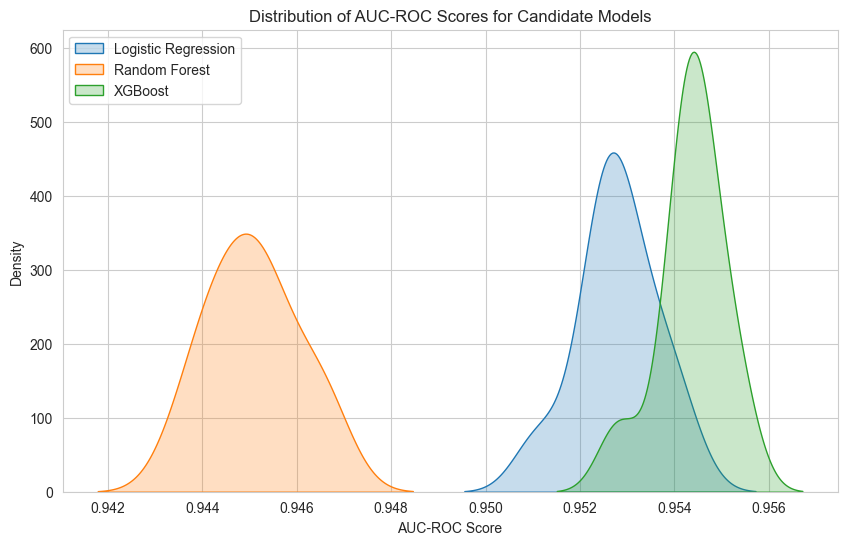

In [88]:
# Plot the distribution of AUC-ROC scores for each candidate model
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
for model_name, cv_scores in scores.items():
    sns.kdeplot(cv_scores, label=model_name, fill=True)
plt.title("Distribution of AUC-ROC Scores for Candidate Models")
plt.xlabel("AUC-ROC Score")
plt.legend()
plt.show()

### 💡 Insight:
- Visually, the XGBoost and Logistic Regression models appear to have performed better than the Random Forest model, with the XGBoost model showing the highest AUC-ROC scores. However, we still need to perform statistical tests to confirm if these differences are significant.

In [89]:
# Evaluate statistical significance of differences between models using Wilcoxon signed-rank test
results = []
model_pairs = list(combinations(candidate_models.keys(), 2))
for model_a, model_b in model_pairs:
    stat, p_value = wilcoxon(scores[model_a], scores[model_b])
    results.append({
        'Model A': model_a,
        'Model B': model_b,
        'Wilcoxon Statistic': stat,
        'p-value': p_value,
        'mean_diff (A - B)': np.mean(scores[model_a] - scores[model_b])
    })

df_results = pd.DataFrame(results)
reject, pvals_corrected, _, _ = multipletests(df_results['p-value'], method='holm')
df_results['p_value_holm'] = pvals_corrected
df_results['reject_null'] = reject
df_results

,Model A,Model B,Wilcoxon Statistic,p-value,mean_diff (A - B),p_value_holm,reject_null
0,Logistic Regression,Random Forest,0.0,0.001953,0.007702,0.005859,True
1,Logistic Regression,XGBoost,0.0,0.001953,-0.001573,0.005859,True
2,Random Forest,XGBoost,0.0,0.001953,-0.009276,0.005859,True


### 💡 Insight:
- The Willcoxon signed-rank test results indicate that the the differences in AUC-ROC scores between the models are statistically significant, with p-values less than 0.05 for all pairwise comparisons.
- The mean differences as well as the visualization of the score distributions suggest that the XGBoost and Logistic Regression models outperform the Random Forest model, with XGBoost showing the highest performance.
- However, the choice between XGBoost and Logistic Regression may depend on other factors such as interpretability, computational resources, and specific use case requirements. Given the similar performance, Logistic Regression may be preferred for its simplicity and interpretability in a healthcare context.

## 7. Hyperparameter tuning

In [90]:
# Define possible hyperparameter values for tuning the Logistic Regression model
param_distributions = {
    "model__C": np.logspace(-4, 4, 20),
    "model__l1_ratio": np.linspace(0, 1, 2)
}

In [91]:
# Hyperparameter tuning for Logistic Regression using RandomizedSearchCV
# To save time, we will only do 10 iterations instead of 50,
# but in a real project we would want to do more extensive tuning to find the best hyperparameters for the model.
# Also, since we are doing hyperparameter tuning, we will use a smaller number of CV splits to speed up the process,
# but in a real project we would want to use more splits for a more robust evaluation.
tunning_run_name = "LR_Hyperparameter_Tuning"
with mlflow.start_run(run_name=tunning_run_name):

    logistic_pipeline = Pipeline([
        ('preprocessor', preprocessor_fe),
        ('model', LogisticRegression(
            random_state=RANDOM_STATE,
            solver='saga'
        ))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    random_search = RandomizedSearchCV(
        estimator=logistic_pipeline,
        param_distributions=param_distributions,
        n_iter=10,
        cv=cv,
        scoring='roc_auc',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=True
    )

    random_search.fit(X_train_fe, y_train)

    best_params = random_search.best_params_
    best_score = random_search.best_score_
    best_std = random_search.cv_results_['std_test_score'][random_search.best_index_]


    # Log parameters
    mlflow.log_params(best_params)

    # Log CV metrics
    mlflow.log_metric("cv_mean_auc", best_score)
    mlflow.log_metric("cv_std_auc", best_std)

    # Log model artifact (candidate model)
    mlflow.sklearn.log_model(
        random_search.best_estimator_,
        artifact_path="candidate_model"
    )

2026/03/13 16:21:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 16:21:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/13 16:21:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


In [92]:
# Get best hyperparameters from the tuning run
client = MlflowClient()
experiment = client.get_experiment_by_name("Heart Disease Prediction - Model Selection")
experiment_id = experiment.experiment_id
best_run = client.search_runs(
    experiment_ids=[experiment_id],
    filter_string='tags.mlflow.runName = "LR_Hyperparameter_Tuning"',
    order_by=["metrics.cv_mean_auc DESC"],
    max_results=1
)[0]
best_params = {
    key.replace("model__", ""): value
    for key, value in best_run.data.params.items()
    if key.startswith("model__")
}

print(f"Best Hyperparameters from Tuning Run: {best_params}")

Best Hyperparameters from Tuning Run: {'C': '29.763514416313132', 'l1_ratio': '0.0'}


### 💡 Insight:
- We will consider proceeding with Logistic Regression (with C=29.7635) as our final model due to its strong performance (very close to XGBoost), simplicity, and interpretability. The tuned hyperparameters will be saved for future reference and use in the final model training and evaluation on the test set.

## 8. Feature importance analysis with best model

Best model run id: c48059a5d8db4c33adda39a476e76f29
Best fitted model: LogisticRegression(C=np.float64(29.763514416313132), l1_ratio=np.float64(0.0),
                   random_state=42, solver='saga')
Test AUC-ROC: 0.9538


,feature,importance
9,cat__Chest pain type_4,2.256887
20,cat__Thallium_7,1.949801
18,cat__Number of vessels fluro_3,1.907902
17,cat__Number of vessels fluro_2,1.857563
19,cat__Thallium_6,1.440382
13,cat__Exercise angina_yes,1.180439
16,cat__Number of vessels fluro_1,1.064607
6,cat__Sex_male,1.044891
14,cat__Slope of ST_2,0.908407
15,cat__Slope of ST_3,0.893080


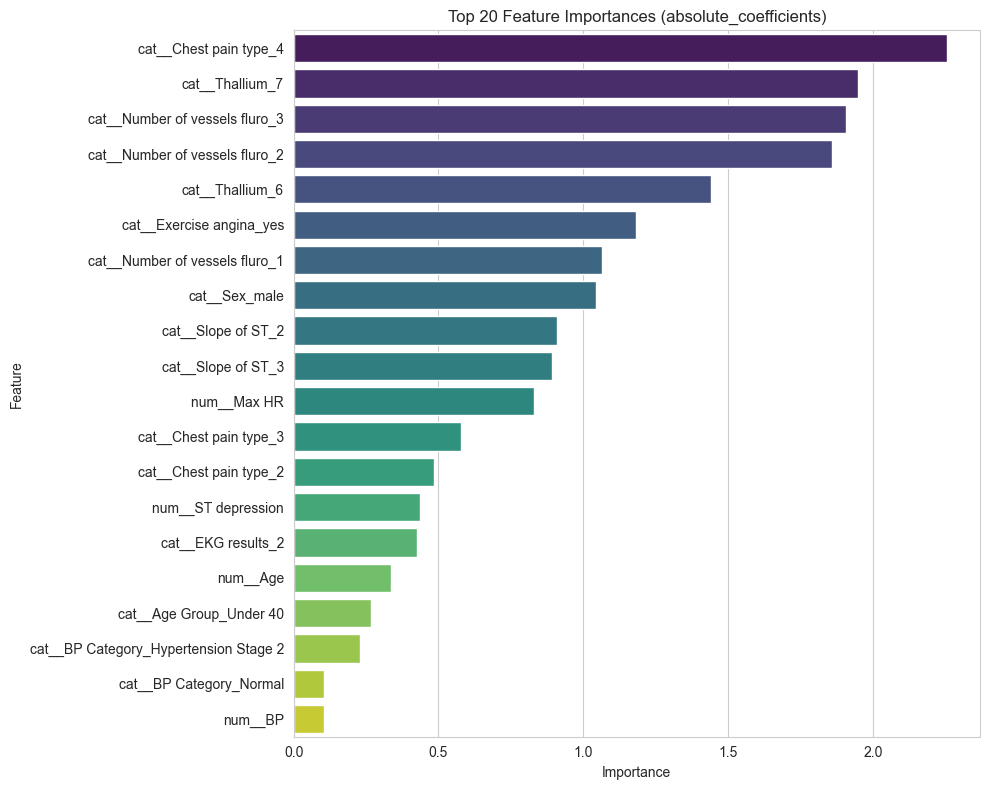

Saved feature importance table to: c:\Users\biell\Documents\projects\potfolio\Predicting-Heart-Disease\artifacts\models\best_model_feature_importance.csv


In [93]:
# Reuse MLflow setup from previous cells and run feature importance
best_run = client.search_runs(
    experiment_ids=[experiment_id],
    filter_string='tags.mlflow.runName = "LR_Hyperparameter_Tuning"',
    order_by=["metrics.cv_mean_auc DESC"],
    max_results=1
)[0]

model_uri = f"runs:/{best_run.info.run_id}/candidate_model"
best_estimator = mlflow.sklearn.load_model(model_uri)

# Fit on train split and evaluate on test split
best_estimator.fit(X_train_fe, y_train)
X_test_fe = create_features(X_test.copy())
test_auc = roc_auc_score(y_test, best_estimator.predict_proba(X_test_fe)[:, 1])
print(f"Best model run id: {best_run.info.run_id}")
print(f"Best fitted model: {best_estimator.named_steps['model']}")
print(f"Test AUC-ROC: {test_auc:.4f}")

# Feature importance
preprocessor = best_estimator.named_steps['preprocessor']
model = best_estimator.named_steps['model']
feature_names = preprocessor.get_feature_names_out()

if hasattr(model, 'coef_'):
    importances = np.abs(model.coef_).ravel()
    importance_method = 'absolute_coefficients'
else:
    perm = permutation_importance(
        best_estimator,
        X_test_fe,
        y_test,
        n_repeats=10,
        random_state=RANDOM_STATE,
        scoring='roc_auc',
        n_jobs=-1
    )
    importances = perm.importances_mean
    importance_method = 'permutation_importance'

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

top_features = feature_importance_df.head(20)
display(top_features)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
plt.title(f'Top 20 Feature Importances ({importance_method})')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

fi_path = MODELS_DIR / 'best_model_feature_importance.csv'
feature_importance_df.to_csv(fi_path, index=False)
print(f"Saved feature importance table to: {fi_path}")

In [94]:
# Add the best model to the models_to_save dictionary for later saving
models_to_save['best_logistic_regression'] = best_estimator

### 💡 Insight:
- The feature importance analysis using Permutation Importance for the best Logistic Regression model revealed that the most influential features for predicting heart disease were:
    1. **Chest Pain Type**: Asymptomatic chest pain was the most important predictor, indicating that patients with this type of chest pain are at higher risk of heart disease.
    2. **Thallium Scan**: Reversible defects in the thallium scan were also highly predictive, suggesting that patients with this finding are more likely to have heart disease.
    3. **Number of Major Vessels**: The number of major vessels colored by fluoroscopy was another important feature, with higher values indicating increased risk.
- On the other hand, features such as Blood Pressure and Blood Pressure Categories were among the least important, suggesting that they may not be strong predictors of heart disease in this dataset. This insight can help guide future feature selection and model refinement efforts.

## 9. Final model training and evaluation on test set

In [95]:
# Train the best model on the full training data
final_pipeline = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        solver='saga',
        C=float(best_params['C']),
        l1_ratio=float(best_params['l1_ratio'])
    ))
])

final_pipeline.fit(X_train_fe, y_train)

y_pred = final_pipeline.predict(X_test_fe)
y_pred_proba = final_pipeline.predict_proba(X_test_fe)[:, 1]

In [96]:
# Add the final model to the models_to_save dictionary for later saving
models_to_save['final_logistic_model'] = final_pipeline

Final Model Test AUC-ROC: 0.9538
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.88      0.89    126000
weighted avg       0.89      0.89      0.89    126000



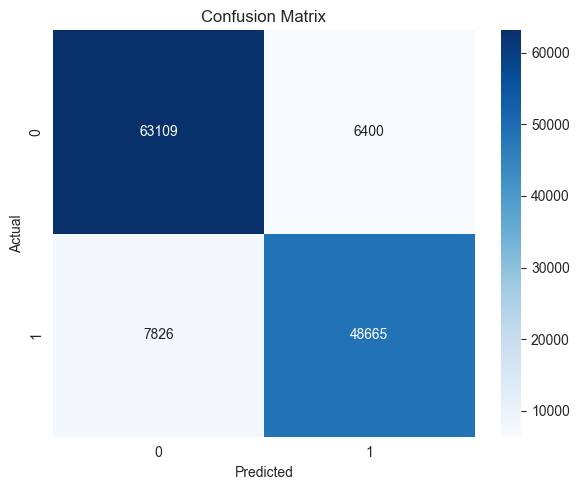

In [97]:
# Evaluate final model performance on the test set
final_test_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Final Model Test AUC-ROC: {final_test_auc:.4f}")

classification_rep = classification_report(y_test, y_pred)
print(f"Classification Report:\n{classification_rep}")

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [98]:
recall_thr_50 = np.mean((y_pred_proba >= 0.5) & (y_test == 1)) / np.mean(y_test == 1)
print(f"Recall at 0.5 threshold: {recall_thr_50:.4f}")

Recall at 0.5 threshold: 0.8615


### 💡 Insight:
- The model achieved a final AUC-ROC of 0.95 and a recall of 0.86 at the 0.5 threshold, indicating strong performance in distinguishing between patients with and without heart disease. The classification report and confusion matrix further support the model's effectiveness, showing high precision and recall for both classes.

## 10. Threshold analysis and final insights

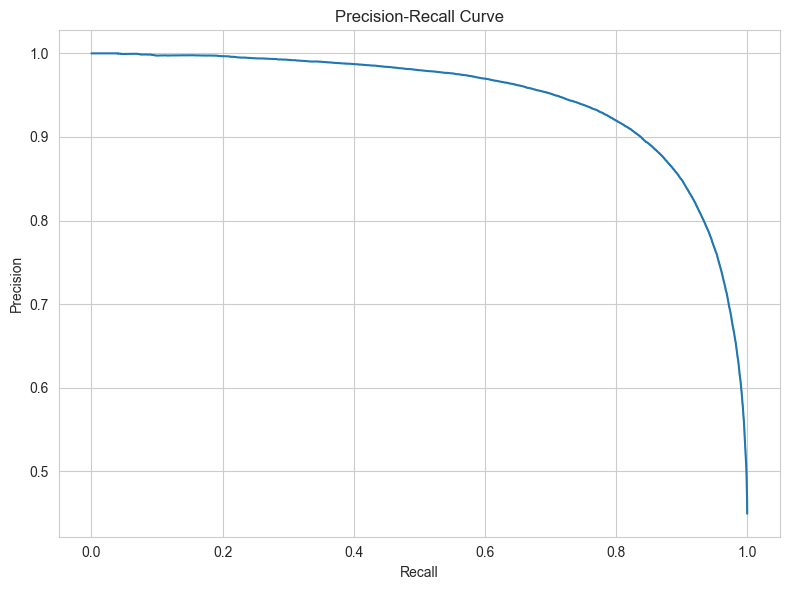

In [99]:
precision_recall_df = pd.DataFrame(precision_recall_curve(y_test, y_pred_proba)).T
precision_recall_df.columns = ['precision', 'recall', 'threshold']
plt.figure(figsize=(8, 6))
sns.lineplot(data=precision_recall_df, x='recall', y='precision')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.tight_layout()
plt.show()

### 💡 Insight:
- Since we are in a healthcare context where false negatives (failing to identify a patient with heart disease) can have severe consequences, we will prioritize recall over precision. Based on the precision-recall curve, we will select a threshold that achieves a recall of at least 0.90, even if it means accepting a lower precision. This approach ensures that we minimize the risk of missing patients with heart disease, which is critical for timely diagnosis and treatment.

In [100]:
TARGET_RECALL = 0.9

threshold_at_target_recall = precision_recall_df.loc[
    (precision_recall_df['recall'] >= TARGET_RECALL)]

ideal_threshold = threshold_at_target_recall['threshold'].max()
print(f"Ideal threshold for recall >= {TARGET_RECALL}: {ideal_threshold:.4f}")
print(f"Recall at ideal threshold: {threshold_at_target_recall.loc[threshold_at_target_recall['threshold'] == ideal_threshold, 'recall'].values[0]:.4f}")
print(f"Precision at ideal threshold: {threshold_at_target_recall.loc[threshold_at_target_recall['threshold'] == ideal_threshold, 'precision'].values[0]:.4f}")

Ideal threshold for recall >= 0.9: 0.3796
Recall at ideal threshold: 0.9000
Precision at ideal threshold: 0.8486


### 💡 Insight:
- By selecting 0.3796 we can achieve a recall of 0.90, which meets our target while maintaining a really good precision of ~0.8. This threshold allows us to identify the majority of patients with heart disease while keeping the number of false positives at a manageable level, which is crucial for clinical decision-making and resource allocation in healthcare settings.

## 11. Final model saving and conclusions

In [101]:
# Save only the models we intentionally want as artifacts
MODELS_DIR.mkdir(parents=True, exist_ok=True)

saved_paths = []
for name, model_obj in models_to_save.items():
    output_path = MODELS_DIR / f"02_modelling_{name}.joblib"
    joblib.dump(model_obj, output_path)
    saved_paths.append(output_path)

print('Saved models:')
for path in saved_paths:
    print(f' - {path.name}')

# Save threshold decision for reproducibility (if available)
if 'ideal_threshold' in globals():
    threshold_info = {
        'model_file': '02_modelling_final_pipeline.joblib',
        'decision_threshold': float(ideal_threshold),
        'selection_rule': 'max threshold with recall >= 0.90',
    }
    threshold_path = MODELS_DIR / '02_modelling_threshold_config.yaml'
    with open(threshold_path, 'w', encoding='utf-8') as f:
        yaml.safe_dump(threshold_info, f, sort_keys=False)
    print(f"Saved threshold config: {threshold_path.name}")

Saved models:
 - 02_modelling_logistic_with_feature_engineering.joblib
 - 02_modelling_best_logistic_regression.joblib
 - 02_modelling_final_logistic_model.joblib
Saved threshold config: 02_modelling_threshold_config.yaml


### Conclusions
- The tuned Logistic Regression model (with feature engineering) delivered strong discrimination, with test AUC-ROC around 0.95.
- Feature importance was clinically plausible: chest pain type, thallium result, and number of vessels were the strongest signals.
- For deployment, threshold tuning improved the clinical trade-off: using a threshold near 0.38 reached about 0.90 recall while keeping precision at a practical level.
- Overall, the model is a solid baseline for screening support, but external validation and calibration are recommended before real-world use.